# **Lab 7**

In this lab, we will do some simple analysis on EMG signals. The data used for this lab is collected in-house on biceps doing curling motion with 3 different weights. We will apply some signal processing steps on the raw EMG data and calculate the integrated EMG (iEMG) of each data to represent the magnitude of muscle action for each specific weight lifted.

Please follow the code to finish the lab, and submit a report based on the provided template on Canvas.

In [55]:
# Scientific packages
import numpy as np
from numpy import linspace, diff, zeros_like, arange, array
from scipy.fft import fft, rfft, rfftfreq
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

**Step 1: Load raw data**

In [56]:
# Sampling frequency of acquired data
fs = 1000 # 1000Hz

# TODO: Load EMG data file
signal = np.genfromtxt('EMG_data\heavy-3885grams.txt')
signal = signal[:,6]

# TODO: Generate the time axis of the signal given its sampling frequency
# hint: length of time and signal should be the same, each 2 timestamps differ by 1/fs
# make sure to convert to numpy array
time = np.arange(len(signal)) / fs

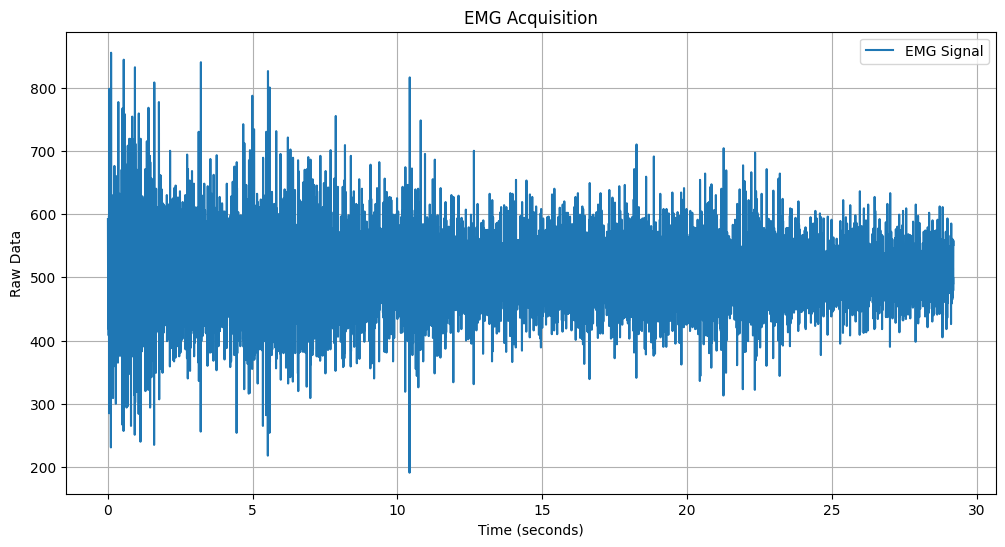

In [57]:
# Visualize the raw EMG signal
plt.figure(figsize=(12, 6))
plt.plot(time, signal, label='EMG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Raw Data')
plt.title('EMG Acquisition')
plt.legend()
plt.grid(True)
plt.show()

**Step 2: Band-pass filter**
Do some quick research for the dominant EMG data frequency band, and apply a band-pass filter to extract that frequency window

In [58]:
# TODO: Bandpass filter the signal according to dominant EMG data range

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

filtered_signal = bandpass_filter(signal, 50, 100, fs)

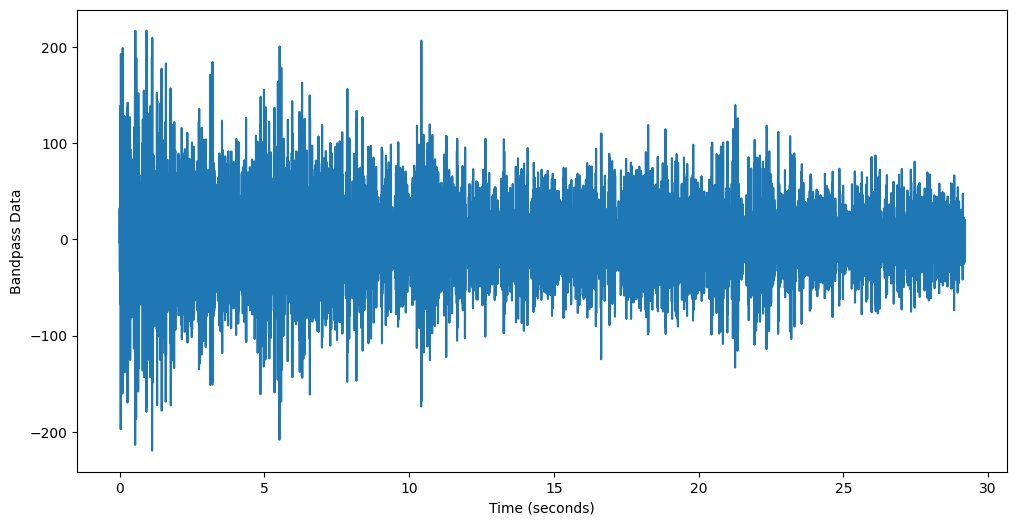

In [59]:
# Visualize the filtered EMG signal
plt.figure(figsize=(12, 6))
plt.plot(time, filtered_signal, label='Post Filtering EMG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Bandpass Data')

plt.show()


**Step 3: Frequency based visualization**
For visualization, let's perform an FFT to the processed signal to visualize the dominant frequency bands. The broad frequency range should align with your bandpass filter. Additionally, if you see a huge peak at 60 Hz, then also apply a notch filter to remove this noise caused by ambient Alternating Current environment.

In [60]:
# TODO: perform FFT to get data in frequency domain

n = len(filtered_signal)
fft_vals = fft(filtered_signal)
fft_freq = rfftfreq(n, 1/fs)
fft_vals = np.abs(rfft(filtered_signal))

# Delete frequency with 0.0Hz
fft_freq = fft_freq[1:]
fft_vals = fft_vals[1:]


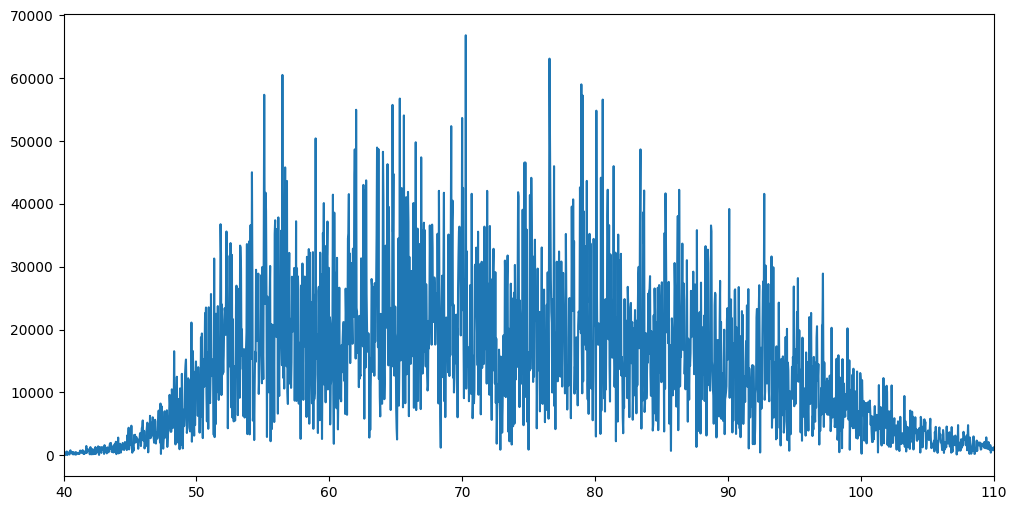

In [61]:
# Plot frequency distribution
# TODO: Make sure to adjust xlim & ylim as needed so that all features are recognizable

plt.figure(figsize=(12, 6))
plt.plot(fft_freq, abs(fft_vals))
plt.xlim(40, 110)
plt.show()

We will also perform a spectrogram to visualize the signal in both frequency and time domains. Since we have done similar actions in the previous labs, you should be able to implement this on your own.

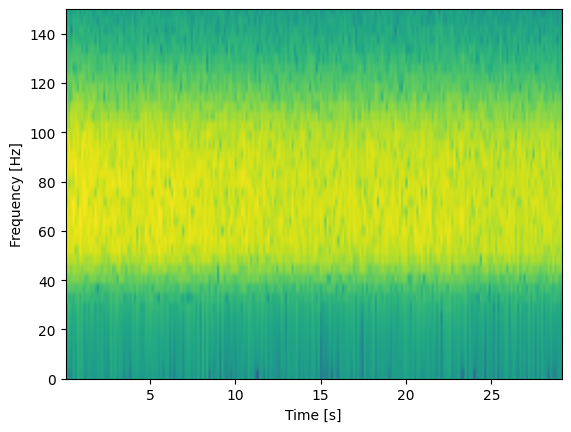

In [62]:
# TODO: plot spectrogram for visualization

plt.specgram(filtered_signal, Fs=fs, NFFT=256, noverlap=128)
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.ylim(0, 150)
plt.show()

**Step 4: Data rectification**
Since EMG is commonly used to measure muscle force, and muscles only generate force along one direction (direction of contraction), there is no such thing as "negative force" during the muscle activity. However, the raw EMG data contains negative values because it is measuring the biopotential of the motor units passing between the two electrodes. Thus, to use the electrical data to represent mechanical force, we can apply rectification to the EMG data to get a closer representation of the muscle force.

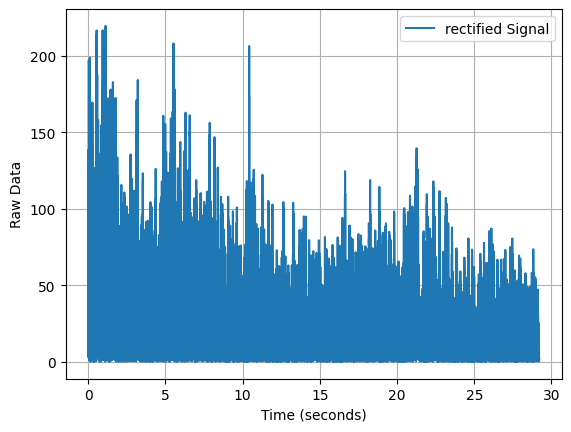

In [63]:
# TODO: Rectify the signal to be positive only

rec_signal = np.abs(filtered_signal)

plt.plot(time, rec_signal, label='rectified Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Raw Data')
plt.legend()
plt.grid(True)
plt.show()


**Step 5: Integrated EMG calculation**
Since muscle contraction is a continuous motion, there likely won't be any individual peak that is representative of the entire motion. Instead, overall muscle work is estimated through integrated EMG (iEMG), which is the area-under-the-curve (AUC) of the rectified data. For the purpose of our provided data, only integrating the middle 10 second of the data (from 10 to 20 seconds) is appropriate.

In [64]:
# TODO: Compute Integrated EMG (iEMG) for a 10 second interval at the middle of
# processed signal (rec_signal)

start_idx = int(10 * fs)
end_idx = int(20 * fs)
segment = rec_signal[start_idx:end_idx]
iEMG_data = np.trapz(segment, dx=1/fs)

print('iEMG of data is: ',iEMG_data)

iEMG of data is:  263.9037505979368


**Step 6: Change of iEMG with respect to weight**
Now that we have a simple pipeline to quantify the muscle action magnitude, please repeat this process for all individual data files, and plot the relationship between weights lifted and iEMG value. Discuss any observed trends, and whether this plot fits your expectations.

In [65]:
# TODO: Calculate the iEMG data for each of the individual data file

iEMG.append((3885, iEMG_data))

In [66]:
iEMG

[(1060, 106.08689115194903),
 (2670, 211.00123250647536),
 (3885, 263.9037505979368)]

In [69]:
res = []
for weight, iEMG_value in iEMG:
    res.append(iEMG_value)

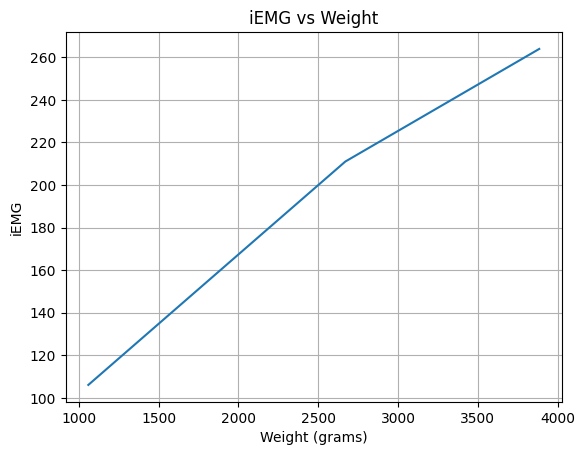

In [70]:
# Plot the change of RMS and iEMG due to change of weight

weight = [1060, 2670, 3885]  # grams

plt.figure()
plt.plot(weight,res)
plt.xlabel('Weight (grams)')
plt.ylabel('iEMG')
plt.title('iEMG vs Weight')
plt.grid(True)
plt.show()

**Step 7: Discussion**

Finally, compile a report showcasing everything you have done. Remember to talk about the parameters you chose for filters and your discussion about the weight vs iEMG plot. Also discuss the differences you observed or learned between processing EMG signals versus and other signals like ECG, including the nature of the signal and the data processing approach.